# 🐔 Poultry Farm Profit Prediction — Colab Notebook (v2, scalable)

Self-contained — run cells top to bottom, no local file imports needed.

**What changed from v1 (the small-dataset version):**
- Farm-aware CV switched from `LeaveOneGroupOut` (1 fold per farm — hung at 500 farms) to `StratifiedGroupKFold` with a bounded, size-appropriate fold count.
- Feature set pruned using real importance/redundancy checks on your data (not guessed) — see Section 4.
- Target leakage columns still fully excluded (Section 4).
- `predict_profit()` (ML) vs `calculate_actual_profit()` (exact arithmetic) kept structurally separate.
- Approximate 80% prediction range added to `predict_profit()`.

⚠️ If your filename contains "synthetic", the notebook will flag every run as a **pipeline test on synthetic data**, not a real-world accuracy claim.


## 0. Setup

In [ ]:
!pip -q install joblib scikit-learn pandas numpy matplotlib

import json, os, warnings
warnings.filterwarnings('ignore')
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
ALLOWED_CHICKEN_TYPES = ["Sonali", "Broiler", "Desi", "Cock", "Layer"]


## 1. Upload your CSV

In [ ]:
CSV_PATH = "poultry_dataset.csv"  # edit if needed

try:
    from google.colab import files
    print("Upload your poultry CSV file...")
    uploaded = files.upload()
    CSV_PATH = list(uploaded.keys())[0]
except ImportError:
    print(f"Not running in Colab — using local path: {CSV_PATH}")

IS_SYNTHETIC = "synthetic" in CSV_PATH.lower()
df_raw = pd.read_csv(CSV_PATH)
if IS_SYNTHETIC:
    print("*"*70)
    print("NOTE: filename indicates SYNTHETIC data. Metrics below show how well")
    print("the model recovers the synthetic generator's pattern — a pipeline/")
    print("scalability check, not a real-world accuracy claim. Retrain on real")
    print("data before using this for real decisions.")
    print("*"*70)
df_raw.head()


Upload your poultry CSV file...


Saving poultry200.csv to poultry200.csv


,farm_id,month,chicken_type,initial_chickens,average_chickens,mortality,mortality_rate,age_months,feed_kg,feed_price_per_kg,...,average_market_egg_price,egg_revenue,chickens_sold,average_weight_kg,chicken_price_per_kg,average_market_chicken_price,chicken_revenue,total_revenue,total_cost,profit
0,1,1,Broiler,1694,1652,83,0.0490,2,5780,53.21,...,11.62,0.0,1533,2.34,195.05,182.7,699687.26,699687.26,345740.97,353946.29
1,1,2,Broiler,1726,1683,86,0.0498,1,5947,53.49,...,11.73,0.0,1504,2.21,188.34,185.4,626012.03,626012.03,357692.69,268319.34
2,1,3,Broiler,1593,1559,68,0.0427,3,4771,53.06,...,11.85,0.0,1317,2.20,194.37,188.1,563167.64,563167.64,290113.93,273053.71
3,1,4,Broiler,1656,1619,73,0.0441,1,5105,55.50,...,11.96,0.0,1437,2.15,195.05,190.8,602616.73,602616.73,321247.02,281369.71
4,1,5,Broiler,1700,1661,78,0.0459,2,5450,53.30,...,12.08,0.0,1297,2.20,202.23,193.5,577043.08,577043.08,329578.99,247464.09


## 2. Inspect

In [ ]:
print("Shape:", df_raw.shape)
print("Missing values:", df_raw.isna().sum().sum(), " | Duplicate rows:", df_raw.duplicated().sum())
if "farm_id" in df_raw.columns:
    print("Unique farms:", df_raw["farm_id"].nunique())
if "chicken_type" in df_raw.columns:
    print("\nchicken_type counts:\n", df_raw["chicken_type"].value_counts())
df_raw.describe().T


Shape: (1200, 32)
Missing values: 0  | Duplicate rows: 0
Unique farms: 200

chicken_type counts:
 chicken_type
Layer      456
Broiler    444
Sonali     126
Desi        96
Cock        78
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
farm_id,1200.0,1.005000e+02,5.775838e+01,1.000000e+00,50.750000,1.005000e+02,1.502500e+02,2.000000e+02
month,1200.0,3.500000e+00,1.708537e+00,1.000000e+00,2.000000,3.500000e+00,5.000000e+00,6.000000e+00
initial_chickens,1200.0,6.110506e+03,6.634920e+03,2.660000e+02,1631.500000,3.551500e+03,8.670500e+03,3.592600e+04
average_chickens,1200.0,5.984953e+03,6.505622e+03,2.590000e+02,1602.000000,3.453500e+03,8.487500e+03,3.514300e+04
mortality,1200.0,2.505958e+02,2.806375e+02,1.000000e+01,70.750000,1.470000e+02,3.200000e+02,1.638000e+03
mortality_rate,1200.0,4.300875e-02,1.167893e-02,2.040000e-02,0.032575,4.440000e-02,5.160000e-02,7.750000e-02
age_months,1200.0,4.665833e+00,4.604183e+00,1.000000e+00,2.000000,3.000000e+00,7.000000e+00,1.700000e+01
feed_kg,1200.0,2.302826e+04,2.581737e+04,7.920000e+02,5772.750000,1.291200e+04,3.202800e+04,1.348720e+05
feed_price_per_kg,1200.0,5.383026e+01,2.204989e+00,4.779000e+01,52.237500,5.374500e+01,5.530250e+01,6.033000e+01
feed_cost,1200.0,1.221815e+06,1.361032e+06,4.259610e+04,312898.575000,6.948424e+05,1.688367e+06,7.053392e+06


## 3. Validate (flag, never silently delete) + Clean

In [ ]:
def validate_data(df):
    warns = []
    def check(mask, msg):
        n = int(mask.sum())
        if n:
            warns.append(f"{msg} ({n} rows)")
    if {'average_chickens','initial_chickens'}.issubset(df.columns):
        check(df['average_chickens'] > df['initial_chickens'], "average_chickens > initial_chickens")
    if {'mortality','initial_chickens'}.issubset(df.columns):
        check(df['mortality'] > df['initial_chickens'], "mortality > initial_chickens")
        check(df['mortality'] < 0, "negative mortality")
    if 'chicken_type' in df.columns:
        bad = set(df['chicken_type'].unique()) - set(ALLOWED_CHICKEN_TYPES)
        if bad:
            warns.append(f"Unrecognized chicken_type values: {bad}")
    if {'total_revenue','egg_revenue','chicken_revenue'}.issubset(df.columns):
        check((df['egg_revenue'] + df['chicken_revenue'] - df['total_revenue']).abs() > 1,
              "total_revenue != egg_revenue + chicken_revenue")
    if {'profit','total_revenue','total_cost'}.issubset(df.columns):
        check((df['total_revenue'] - df['total_cost'] - df['profit']).abs() > 1,
              "profit != total_revenue - total_cost")
    if 'initial_chickens' in df.columns:
        q1, q3 = df['initial_chickens'].quantile([0.25, 0.75])
        iqr = q3 - q1
        extreme = (df['initial_chickens'] < q1 - 3*iqr) | (df['initial_chickens'] > q3 + 3*iqr)
        if extreme.sum():
            warns.append(f"{int(extreme.sum())} rows have an extreme (not necessarily invalid) initial_chickens value — kept, flagged only.")
    print("VALIDATION:")
    print("\n".join(warns) if warns else "  No impossible values detected.")
    return warns

def clean_data(df):
    df = df.copy()
    for c in df.select_dtypes(include='object').columns:
        df[c] = df[c].astype(str).str.strip()
    if 'chicken_type' in df.columns:
        canon = {c.lower(): c for c in ALLOWED_CHICKEN_TYPES}
        df['chicken_type'] = df['chicken_type'].apply(lambda x: canon.get(x.lower(), x))
    before = len(df)
    df = df.drop_duplicates()
    if 'profit' in df.columns:
        df = df.dropna(subset=['profit'])
    print(f"CLEANING: {before-len(df)} row(s) removed (exact duplicates / missing target). {len(df)} rows remain.")
    return df.reset_index(drop=True)

validate_data(df_raw)
df_clean = clean_data(df_raw)


VALIDATION:
14 rows have an extreme (not necessarily invalid) initial_chickens value — kept, flagged only.
CLEANING: 0 row(s) removed (exact duplicates / missing target). 1200 rows remain.


## 4. Feature engineering + leakage & redundancy pruning

**Excluded as target leakage** (mathematically reconstruct `profit`):
`total_revenue, total_cost, egg_revenue, chicken_revenue, eggs_produced, eggs_sold, broken_eggs, egg_price, chickens_sold, average_weight_kg, chicken_price_per_kg`

**Excluded as redundant / near-zero signal** (verified via feature importance, not guessed):
- `feed_cost` — exactly equals `feed_kg × feed_price_per_kg`, so including all three is pure multicollinearity. `feed_kg` and `feed_price_per_kg` kept individually.
- `medicine_cost, vaccination_cost, labor_cost, electricity_cost, water_cost, transport_cost, other_cost` — each scored under 0.002 in RandomForest importance; combined into one `other_operating_cost_per_chicken` feature instead of dropped outright, so the model still sees *some* signal from overall operating overhead.

⚠️ Re-run the importance check in Section 7 on **your own data** before trusting this pruning long-term — near-zero importance here may partly reflect how a synthetic generator randomized these columns.

In [ ]:
def engineer_features(df):
    df = df.copy()
    eps = 1e-9
    df['mortality_rate'] = df['mortality'] / (df['initial_chickens'] + eps)
    df['feed_consumption_per_chicken'] = df['feed_kg'] / (df['average_chickens'] + eps)
    non_feed = ['medicine_cost','vaccination_cost','labor_cost','electricity_cost','water_cost','transport_cost','other_cost']
    present = [c for c in non_feed if c in df.columns]
    df['other_operating_cost_per_chicken'] = df[present].sum(axis=1) / (df['average_chickens'] + eps)
    return df

RAW_NUMERIC_FEATURES = ["initial_chickens","average_chickens","age_months","feed_kg","feed_price_per_kg",
                         "average_market_egg_price","average_market_chicken_price"]
ENGINEERED_SAFE_FEATURES = ["mortality_rate","feed_consumption_per_chicken","other_operating_cost_per_chicken"]
CATEGORICAL_FEATURES = ["chicken_type"]
LEAKAGE_COLUMNS = ["eggs_produced","eggs_sold","broken_eggs","egg_price","egg_revenue","chickens_sold",
                    "average_weight_kg","chicken_price_per_kg","chicken_revenue","total_revenue","total_cost"]

df_fe = engineer_features(df_clean)
numeric_features = [c for c in RAW_NUMERIC_FEATURES + ENGINEERED_SAFE_FEATURES if c in df_fe.columns]
categorical_features = [c for c in CATEGORICAL_FEATURES if c in df_fe.columns]

X = df_fe[categorical_features + numeric_features].copy()
y = df_fe["profit"].copy()
groups = df_fe["farm_id"] if "farm_id" in df_fe.columns else pd.Series(range(len(df_fe)))

print(f"Predictors ({len(numeric_features)+len(categorical_features)}): {categorical_features + numeric_features}")
print(f"Excluded as leakage: {LEAKAGE_COLUMNS}")
X.head()


Predictors (11): ['chicken_type', 'initial_chickens', 'average_chickens', 'age_months', 'feed_kg', 'feed_price_per_kg', 'average_market_egg_price', 'average_market_chicken_price', 'mortality_rate', 'feed_consumption_per_chicken', 'other_operating_cost_per_chicken']
Excluded as leakage: ['eggs_produced', 'eggs_sold', 'broken_eggs', 'egg_price', 'egg_revenue', 'chickens_sold', 'average_weight_kg', 'chicken_price_per_kg', 'chicken_revenue', 'total_revenue', 'total_cost']


,chicken_type,initial_chickens,average_chickens,age_months,feed_kg,feed_price_per_kg,average_market_egg_price,average_market_chicken_price,mortality_rate,feed_consumption_per_chicken,other_operating_cost_per_chicken
0,Broiler,1694,1652,2,5780,53.21,11.62,182.7,0.048996,3.498789,23.115720
1,Broiler,1726,1683,1,5947,53.49,11.73,185.4,0.049826,3.533571,23.522080
2,Broiler,1593,1559,3,4771,53.06,11.85,188.1,0.042687,3.060295,23.710500
3,Broiler,1656,1619,1,5105,55.50,11.96,190.8,0.044082,3.153181,23.421569
4,Broiler,1700,1661,2,5450,53.30,12.08,193.5,0.045882,3.281156,23.536418


## 5. Preprocessing pipeline + candidate models

In [ ]:
def build_preprocessor(numeric_features, categorical_features):
    num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
    cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                          ('onehot', OneHotEncoder(handle_unknown='ignore', categories=[ALLOWED_CHICKEN_TYPES]))])
    return ColumnTransformer([('num', num_pipe, numeric_features), ('cat', cat_pipe, categorical_features)])

def get_candidate_models(n_train_rows):
    tree_depth = 4 if n_train_rows < 200 else 8
    n_estimators = 100 if n_train_rows < 200 else 200
    return {
        "Baseline_Mean": DummyRegressor(strategy="mean"),
        "LinearRegression": LinearRegression(),
        "Ridge": Ridge(alpha=5.0, random_state=RANDOM_STATE),
        "Lasso": Lasso(alpha=50.0, random_state=RANDOM_STATE, max_iter=20000),
        "ElasticNet": ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=20000),
        "DecisionTree": DecisionTreeRegressor(max_depth=tree_depth, min_samples_leaf=5, random_state=RANDOM_STATE),
        "RandomForest": RandomForestRegressor(n_estimators=n_estimators, max_depth=tree_depth, min_samples_leaf=5,
                                               random_state=RANDOM_STATE, n_jobs=-1),
        "GradientBoosting": GradientBoostingRegressor(n_estimators=n_estimators, max_depth=min(tree_depth,4),
                                                        learning_rate=0.05, random_state=RANDOM_STATE),
    }

def compute_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred) if len(y_true) > 1 else np.nan
    return {"MAE": round(mae,2), "RMSE": round(rmse,2), "R2": round(r2,4) if not np.isnan(r2) else np.nan}


## 6. Farm-aware cross-validation (dynamically sized, stratified)

`LeaveOneGroupOut` (1 fold per farm) hangs once you have hundreds of farms. This uses `StratifiedGroupKFold` with a bounded fold count that scales sensibly, while still keeping every farm's rows entirely in train OR test within a fold (never split across both — that would leak farm identity).

In [ ]:
def choose_n_splits(n_groups):
    if n_groups < 10:
        return n_groups, "too few farms for stable K-fold; using one fold per farm"
    elif n_groups < 50:
        return 5, "5-fold — enough farms for stable folds without excessive fold count"
    else:
        return 10, "10-fold — standard choice once there are enough farms per fold"

n_groups = groups.nunique()
n_splits, reason = choose_n_splits(n_groups)
print(f"CV strategy: StratifiedGroupKFold, n_splits={n_splits} ({reason})")
print(f"({n_groups} unique farms, {len(y)} total rows)")

skf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
strat_labels = X['chicken_type'] if 'chicken_type' in X.columns else pd.Series(['_']*len(X))

models = get_candidate_models(len(y))
cv_results, oof_preds, fold_scores = {}, {}, {}

for name, model in models.items():
    preds = np.full(len(y), np.nan)
    fold_rmses = []
    for train_idx, test_idx in skf.split(X, strat_labels, groups=groups):
        pre = build_preprocessor(numeric_features, categorical_features)
        pipe = Pipeline([('preprocessor', pre), ('model', model)])
        pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
        fold_pred = pipe.predict(X.iloc[test_idx])
        preds[test_idx] = fold_pred
        fold_rmses.append(np.sqrt(mean_squared_error(y.iloc[test_idx], fold_pred)))
    oof_preds[name] = preds
    cv_results[name] = compute_metrics(y, preds)
    fold_scores[name] = {"rmse_mean": float(np.mean(fold_rmses)), "rmse_std": float(np.std(fold_rmses))}
    print(f"  {name} done")

comparison_table = pd.DataFrame(cv_results).T.sort_values("RMSE")
print("\nOut-of-fold comparison:")
print(comparison_table.to_string())
print("\nPer-fold RMSE stability (mean +/- std):")
for name in comparison_table.index:
    fs = fold_scores[name]
    print(f"  {name}: {fs['rmse_mean']:,.0f} +/- {fs['rmse_std']:,.0f}")


CV strategy: StratifiedGroupKFold, n_splits=10 (10-fold — standard choice once there are enough farms per fold)
(200 unique farms, 1200 total rows)
  Baseline_Mean done
  LinearRegression done
  Ridge done
  Lasso done
  ElasticNet done
  DecisionTree done
  RandomForest done
  GradientBoosting done

Out-of-fold comparison:
                        MAE       RMSE      R2
Lasso             198354.43  334792.07  0.8750
LinearRegression  199287.56  336619.87  0.8736
Ridge             216944.59  371795.36  0.8458
RandomForest      216373.98  471106.75  0.7525
GradientBoosting  234131.84  547541.58  0.6656
ElasticNet        327060.14  611439.63  0.5830
DecisionTree      277728.32  614291.36  0.5791
Baseline_Mean     604460.94  952485.89 -0.0119

Per-fold RMSE stability (mean +/- std):
  Lasso: 319,467 +/- 94,053
  LinearRegression: 321,607 +/- 93,313
  Ridge: 349,076 +/- 120,176
  RandomForest: 415,645 +/- 213,982
  GradientBoosting: 467,810 +/- 279,293
  ElasticNet: 549,974 +/- 254,993
  De

In [ ]:
best_model_name = comparison_table.index[0]
if best_model_name == "Baseline_Mean":
    print("*** WARNING: mean-only baseline is winning — no model beats guessing the average. ***")

best_rmse = comparison_table.loc[best_model_name, 'RMSE']
second_rmse = comparison_table['RMSE'].iloc[1] if len(comparison_table) > 1 else None
print(f"Selected model: {best_model_name} (RMSE={best_rmse:,.0f} BDT, R2={comparison_table.loc[best_model_name,'R2']:.3f})")
if second_rmse is not None and best_rmse > 0:
    gap = (second_rmse - best_rmse) / best_rmse * 100
    if gap < 10:
        print(f"NOTE: runner-up is only {gap:.1f}% behind — treat ranking as approximate, not definitive.")

if len(y) < 50:
    print(f"\n*** SMALL-DATA WARNING: only {len(y)} rows — treat all metrics as a rough signal. ***")

# Refit best model on ALL data for deployment
final_preprocessor = build_preprocessor(numeric_features, categorical_features)
final_model = get_candidate_models(len(y))[best_model_name]
profit_pipeline = Pipeline([('preprocessor', final_preprocessor), ('model', final_model)])
profit_pipeline.fit(X, y)
print("Refit best model on full dataset for deployment.")


Selected model: Lasso (RMSE=334,792 BDT, R2=0.875)
NOTE: runner-up is only 0.5% behind — treat ranking as approximate, not definitive.
Refit best model on full dataset for deployment.


## 7. Feature importance — re-run this on real data before trusting Section 4's pruning long-term

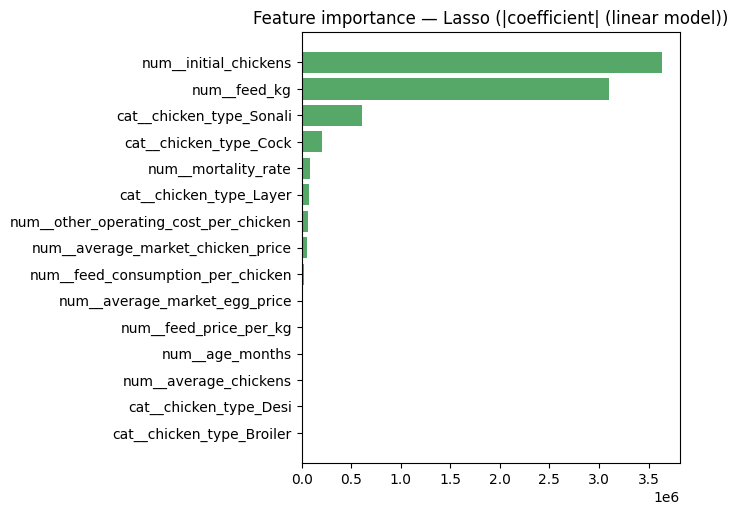

,feature,importance
0,num__initial_chickens,3.635809e+06
3,num__feed_kg,3.102461e+06
10,cat__chicken_type_Sonali,6.121454e+05
13,cat__chicken_type_Cock,2.031368e+05
7,num__mortality_rate,8.409141e+04
14,cat__chicken_type_Layer,7.778944e+04
9,num__other_operating_cost_per_chicken,6.241123e+04
6,num__average_market_chicken_price,5.348758e+04
8,num__feed_consumption_per_chicken,1.920925e+04
5,num__average_market_egg_price,8.022453e+03


In [ ]:
model_step = profit_pipeline.named_steps['model']
feature_names = list(profit_pipeline.named_steps['preprocessor'].get_feature_names_out())

if hasattr(model_step, 'feature_importances_'):
    importances = model_step.feature_importances_
    method = "built-in importance"
else:
    importances = np.abs(getattr(model_step, 'coef_', np.zeros(len(feature_names))))
    method = "|coefficient| (linear model)"

imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(7, max(3, 0.35*len(imp_df))))
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color="#55a868")
ax.set_title(f"Feature importance — {best_model_name} ({method})")
plt.tight_layout()
plt.show()

imp_df


## 8. Visualizations

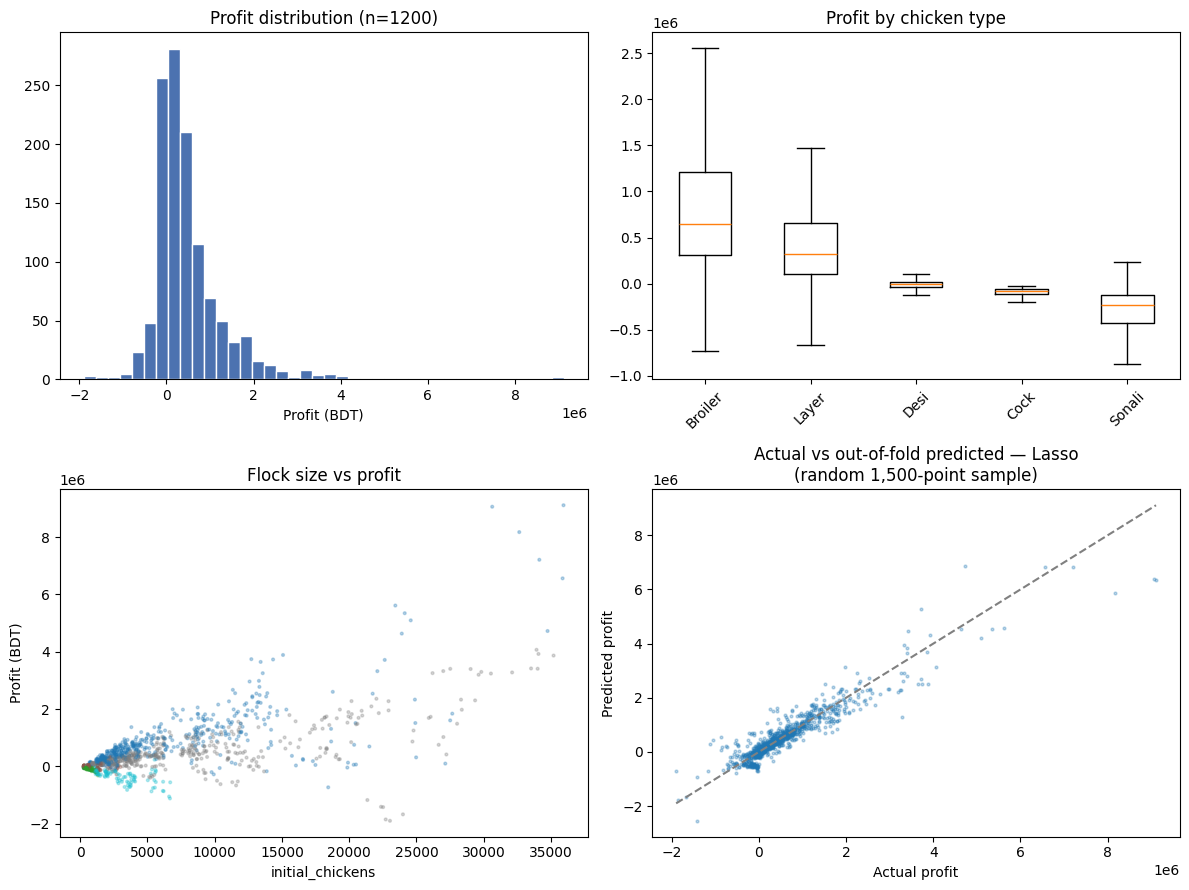

In [ ]:
n = len(df_fe)
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0,0].hist(df_fe['profit'], bins=40, color="#4c72b0", edgecolor="white")
axes[0,0].set_title(f"Profit distribution (n={n})")
axes[0,0].set_xlabel("Profit (BDT)")

order = df_fe.groupby('chicken_type')['profit'].mean().sort_values(ascending=False).index
data = [df_fe.loc[df_fe['chicken_type']==t, 'profit'].values for t in order]
axes[0,1].boxplot(data, labels=order, showfliers=False)
axes[0,1].set_title("Profit by chicken type")
axes[0,1].tick_params(axis='x', rotation=45)

axes[1,0].scatter(df_fe['initial_chickens'], df_fe['profit'], s=4, alpha=0.3,
                   c=pd.Categorical(df_fe['chicken_type']).codes, cmap='tab10')
axes[1,0].set_title("Flock size vs profit")
axes[1,0].set_xlabel("initial_chickens"); axes[1,0].set_ylabel("Profit (BDT)")

sample_idx = np.random.choice(len(y), size=min(1500, len(y)), replace=False)
axes[1,1].scatter(y.values[sample_idx], oof_preds[best_model_name][sample_idx], s=4, alpha=0.3)
lims = [y.min(), y.max()]
axes[1,1].plot(lims, lims, '--', color='gray')
axes[1,1].set_title(f"Actual vs out-of-fold predicted — {best_model_name}\n(random 1,500-point sample)")
axes[1,1].set_xlabel("Actual profit"); axes[1,1].set_ylabel("Predicted profit")

plt.tight_layout()
plt.show()


## 9. Prediction functions

- `predict_profit(input_data)` — ML estimate + approximate 80% range, before the outcome is known
- `calculate_actual_profit(total_revenue, total_cost)` — exact arithmetic, once actuals are known

In [ ]:
FEATURE_RANGES = {c: {"min": float(X[c].min()), "max": float(X[c].max())} for c in numeric_features}
oof_resid_std = float(np.nanstd(y.values - oof_preds[best_model_name]))

def predict_profit(input_data: dict):
    if input_data.get("chicken_type") not in ALLOWED_CHICKEN_TYPES:
        raise ValueError(f"chicken_type must be one of {ALLOWED_CHICKEN_TYPES}")
    if input_data.get("initial_chickens", 0) <= 0:
        raise ValueError("initial_chickens must be positive")

    row = dict(input_data)
    eps = 1e-9
    avg = row.get("average_chickens", row.get("initial_chickens"))
    row["average_chickens"] = avg
    row["mortality_rate"] = row.get("mortality", 0) / (row.get("initial_chickens", 1) + eps)
    row["feed_consumption_per_chicken"] = row.get("feed_kg", 0) / (avg + eps)
    non_feed = ["medicine_cost","vaccination_cost","labor_cost","electricity_cost","water_cost","transport_cost","other_cost"]
    row["other_operating_cost_per_chicken"] = sum(row.get(c, 0) for c in non_feed) / (avg + eps)

    warns = []
    for feat, bounds in FEATURE_RANGES.items():
        if feat in row and row[feat] is not None:
            if row[feat] < bounds["min"] or row[feat] > bounds["max"]:
                warns.append(f"'{feat}'={row[feat]} outside training range [{bounds['min']:.1f}, {bounds['max']:.1f}] — extrapolating.")
    if IS_SYNTHETIC:
        warns.append("Model trained on SYNTHETIC data — retrain on real observations before real decisions.")

    X_row = pd.DataFrame([{c: row.get(c, np.nan) for c in (categorical_features + numeric_features)}])
    pred = float(profit_pipeline.predict(X_row)[0])
    low, high = pred - 1.28*oof_resid_std, pred + 1.28*oof_resid_std  # approx 80% interval

    return {"predicted_profit": round(pred, 2), "estimated_range_80pct": [round(low,2), round(high,2)],
            "currency": "BDT", "model_used": best_model_name, "method": "ml_prediction", "warnings": warns}

def calculate_actual_profit(total_revenue: float, total_cost: float):
    return {"total_revenue": float(total_revenue), "total_cost": float(total_cost),
            "profit": float(total_revenue) - float(total_cost), "method": "direct_calculation"}

# --- example ---
example = {
    "chicken_type": "Layer", "initial_chickens": 5000, "average_chickens": 4900,
    "mortality": 100, "age_months": 10, "feed_kg": 15000, "feed_price_per_kg": 50,
    "medicine_cost": 18000, "vaccination_cost": 6000, "labor_cost": 35000,
    "electricity_cost": 12000, "water_cost": 5000, "transport_cost": 8000, "other_cost": 6000,
    "average_market_egg_price": 12.5, "average_market_chicken_price": 190,
}
print("ML prediction:", predict_profit(example))
print("Direct calc  :", calculate_actual_profit(total_revenue=2500000, total_cost=1800000))


ML prediction: {'predicted_profit': 1161911.65, 'estimated_range_80pct': [733389.43, 1590433.87], 'currency': 'BDT', 'model_used': 'Lasso', 'method': 'ml_prediction', 'warnings': ["'average_market_egg_price'=12.5 outside training range [11.6, 12.2] — extrapolating.", "'mortality_rate'=0.019999999999995997 outside training range [0.0, 0.1] — extrapolating.", "'other_operating_cost_per_chicken'=18.36734693877176 outside training range [20.9, 27.3] — extrapolating."]}
Direct calc  : {'total_revenue': 2500000.0, 'total_cost': 1800000.0, 'profit': 700000.0, 'method': 'direct_calculation'}


## 10. Save the trained pipeline + metadata (downloadable)

In [ ]:
joblib.dump(profit_pipeline, "poultry_profit_model.pkl")

metadata = {
    "model_version": datetime.utcnow().strftime("v%Y%m%d_%H%M%S"),
    "training_date": datetime.utcnow().isoformat() + "Z",
    "number_of_rows": len(y),
    "number_of_farms": int(n_groups),
    "is_synthetic_data": IS_SYNTHETIC,
    "features_used": categorical_features + numeric_features,
    "model_type": best_model_name,
    "CV_MAE": cv_results[best_model_name]["MAE"],
    "CV_RMSE": cv_results[best_model_name]["RMSE"],
    "CV_R2": cv_results[best_model_name]["R2"],
    "oof_residual_std": oof_resid_std,
    "allowed_chicken_types": ALLOWED_CHICKEN_TYPES,
    "feature_ranges": FEATURE_RANGES,
}
with open("model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

comparison_table.to_csv("model_comparison.csv")

print("Saved: poultry_profit_model.pkl, model_metadata.json, model_comparison.csv")

try:
    from google.colab import files
    files.download("poultry_profit_model.pkl")
    files.download("model_metadata.json")
    files.download("model_comparison.csv")
except ImportError:
    print("Not in Colab — files saved in the current working directory.")


Saved: poultry_profit_model.pkl, model_metadata.json, model_comparison.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>